# Patterns in the Book of Mormon
### An unsupervised-learning tour of the text

This notebook lets the algorithms loose on the Book of Mormon — no labels, no hypotheses, just structure-finding. Everything runs from `data/scriptures.csv` in this repo, so the whole analysis is reproducible top-to-bottom.

**What's inside**

1. **The shape of the record** — how the words are distributed across books
2. **Vocabulary** — what the text talks about, and what each book talks about *distinctively*
3. **"And it came to pass"** — the famous phrase, and other formulaic n-grams
4. **Topic modeling (NMF)** — themes the machine discovers on its own, and how they flow across the narrative
5. **Chapter clustering + UMAP** — do chapters group into natural families?
6. **Stylometry** — do the books have measurably different *styles* (not just subjects)?
7. **Verse echoes** — the most similar verse pairs across different books
8. **Vocabulary novelty** — where new language enters the record

In [1]:
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF, PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram

warnings.filterwarnings("ignore")
RNG = 42
np.random.seed(RNG)

In [2]:
# ---- Plot styling ------------------------------------------------------------
# A small validated palette (colorblind-checked), plus a house plotly template.
SERIES = ["#2a78d6", "#008300", "#e87ba4", "#eda100",
          "#1baf7a", "#eb6834", "#4a3aa7", "#e34948"]
SEQ_BLUE = ["#eaf1fb", "#c7dbf4", "#9dc0ea", "#6fa2de", "#4589d9", "#2a78d6", "#1d5aa6", "#123d73"]
SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"

TEMPLATE = go.layout.Template(layout=dict(
    font=dict(family="Georgia, 'Times New Roman', serif", color=INK, size=14),
    title=dict(font=dict(size=20), x=0.02, xanchor="left"),
    paper_bgcolor=SURFACE, plot_bgcolor=SURFACE,
    xaxis=dict(gridcolor="#e8e7e3", zerolinecolor="#d8d7d2", ticks="outside", tickcolor="#d8d7d2"),
    yaxis=dict(gridcolor="#e8e7e3", zerolinecolor="#d8d7d2", ticks="outside", tickcolor="#d8d7d2"),
    margin=dict(l=70, r=30, t=70, b=60),
    colorway=SERIES,
))
pio.templates["scripture"] = TEMPLATE
pio.templates.default = "scripture"

# Render figures as static PNGs so they display anywhere (GitHub included).
# Falls back to interactive HTML if no Chrome/Chromium is available for kaleido.
import glob, os, shutil
try:
    if not (shutil.which("google-chrome") or shutil.which("chromium") or os.environ.get("BROWSER_PATH")):
        hits = glob.glob("/opt/pw-browsers/chromium*/chrome-linux/chrome")
        if hits:
            os.environ["BROWSER_PATH"] = hits[0]
    go.Figure(go.Scatter(x=[0], y=[0])).to_image(format="png")
    pio.renderers.default = "png"
    pio.defaults.default_scale = 2
    print("Rendering figures as static PNG (portable).")
except Exception as e:
    pio.renderers.default = "notebook"
    print("Kaleido unavailable; using interactive renderer.", e)

Rendering figures as static PNG (portable).


## 0 · Load the text

The source file has every standard work; we keep only the Book of Mormon. We build two views of the text: one row per **verse** (6,604 of them) and one row per **chapter** (239), with books kept in narrative order.

In [3]:
df = pd.read_csv("data/scriptures.csv")
bom = df[df.volume_title == "Book of Mormon"].copy().reset_index(drop=True)

BOOK_ORDER = ["1 Nephi", "2 Nephi", "Jacob", "Enos", "Jarom", "Omni",
              "Words of Mormon", "Mosiah", "Alma", "Helaman", "3 Nephi",
              "4 Nephi", "Mormon", "Ether", "Moroni"]
bom["book_title"] = pd.Categorical(bom.book_title, categories=BOOK_ORDER, ordered=True)
bom["n_words"] = bom.scripture_text.str.split().str.len()

chapters = (bom.groupby(["book_title", "chapter_number"], observed=True)
               .agg(text=("scripture_text", " ".join),
                    n_verses=("verse_number", "size"),
                    n_words=("n_words", "sum"))
               .reset_index())
chapters["label"] = chapters.book_title.astype(str) + " " + chapters.chapter_number.astype(str)
chapters = chapters.sort_values(["book_title", "chapter_number"]).reset_index(drop=True)
chapters["seq"] = np.arange(len(chapters))  # narrative position 0..238

print(f"{len(bom):,} verses · {len(chapters)} chapters · {len(BOOK_ORDER)} books · {bom.n_words.sum():,} words")

6,604 verses · 239 chapters · 15 books · 266,938 words


## 1 · The shape of the record

First, the raw proportions. The record is famously lopsided — a couple of books carry most of the text.

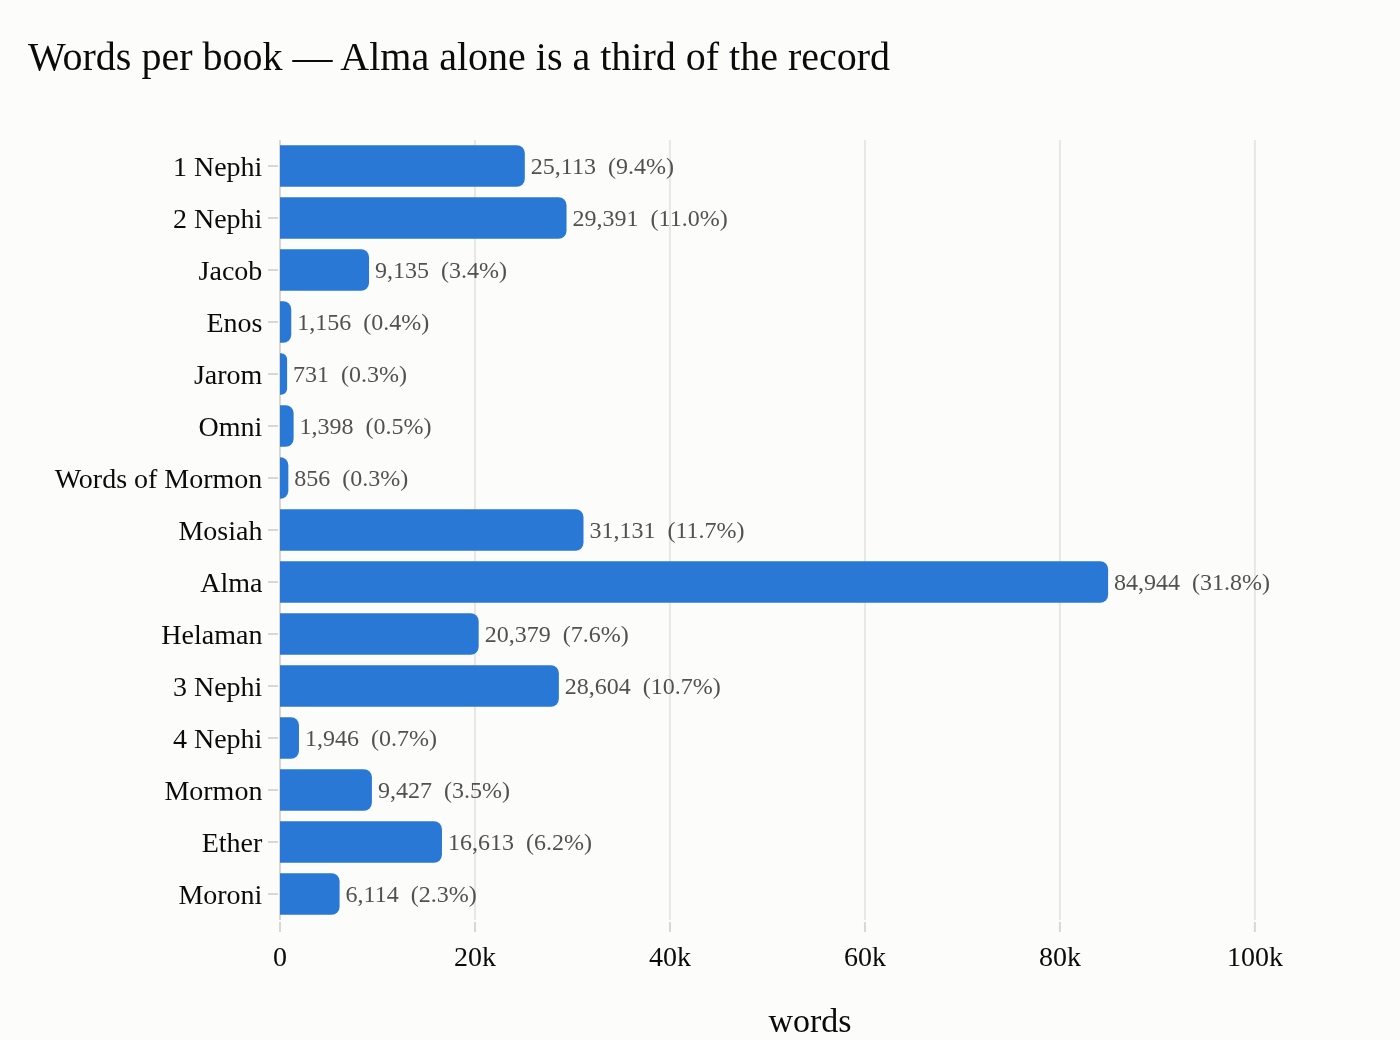

book_title,1 Nephi,2 Nephi,Jacob,Enos,Jarom,Omni,Words of Mormon,Mosiah,Alma,Helaman,3 Nephi,4 Nephi,Mormon,Ether,Moroni
words,25113.0,29391.0,9135.0,1156.0,731.0,1398.0,856.0,31131.0,84944.0,20379.0,28604.0,1946.0,9427.0,16613.0,6114.0
verses,618.0,779.0,203.0,27.0,15.0,30.0,18.0,785.0,1975.0,497.0,785.0,49.0,227.0,433.0,163.0
chapters,22.0,33.0,7.0,1.0,1.0,1.0,1.0,29.0,63.0,16.0,30.0,1.0,9.0,15.0,10.0
share,9.4,11.0,3.4,0.4,0.3,0.5,0.3,11.7,31.8,7.6,10.7,0.7,3.5,6.2,2.3


In [4]:
book_stats = (bom.groupby("book_title", observed=True)
                 .agg(words=("n_words", "sum"), verses=("verse_number", "size"))
                 .reindex(BOOK_ORDER))
book_stats["chapters"] = chapters.book_title.value_counts().reindex(BOOK_ORDER)
share = book_stats.words / book_stats.words.sum() * 100

fig = go.Figure(go.Bar(
    y=book_stats.index[::-1], x=book_stats.words[::-1], orientation="h",
    marker=dict(color="#2a78d6", cornerradius=4),
    text=[f"{w:,}  ({s:.1f}%)" for w, s in zip(book_stats.words[::-1], share[::-1])],
    textposition="outside", textfont=dict(color=INK2, size=12),
    hovertemplate="<b>%{y}</b><br>%{x:,} words<extra></extra>"))
fig.update_layout(title="Words per book — Alma alone is a third of the record",
                  xaxis_title="words", height=520, xaxis_range=[0, book_stats.words.max()*1.28],
                  yaxis=dict(gridcolor="rgba(0,0,0,0)"), margin=dict(l=140))
fig.show()
book_stats.assign(share=share.round(1)).T

## 2 · Vocabulary

### 2a — What the whole record talks about
We strip standard English stop words **plus** the scriptural function words (*unto, yea, behold, hath…*) that would otherwise drown everything. What remains is the content vocabulary.

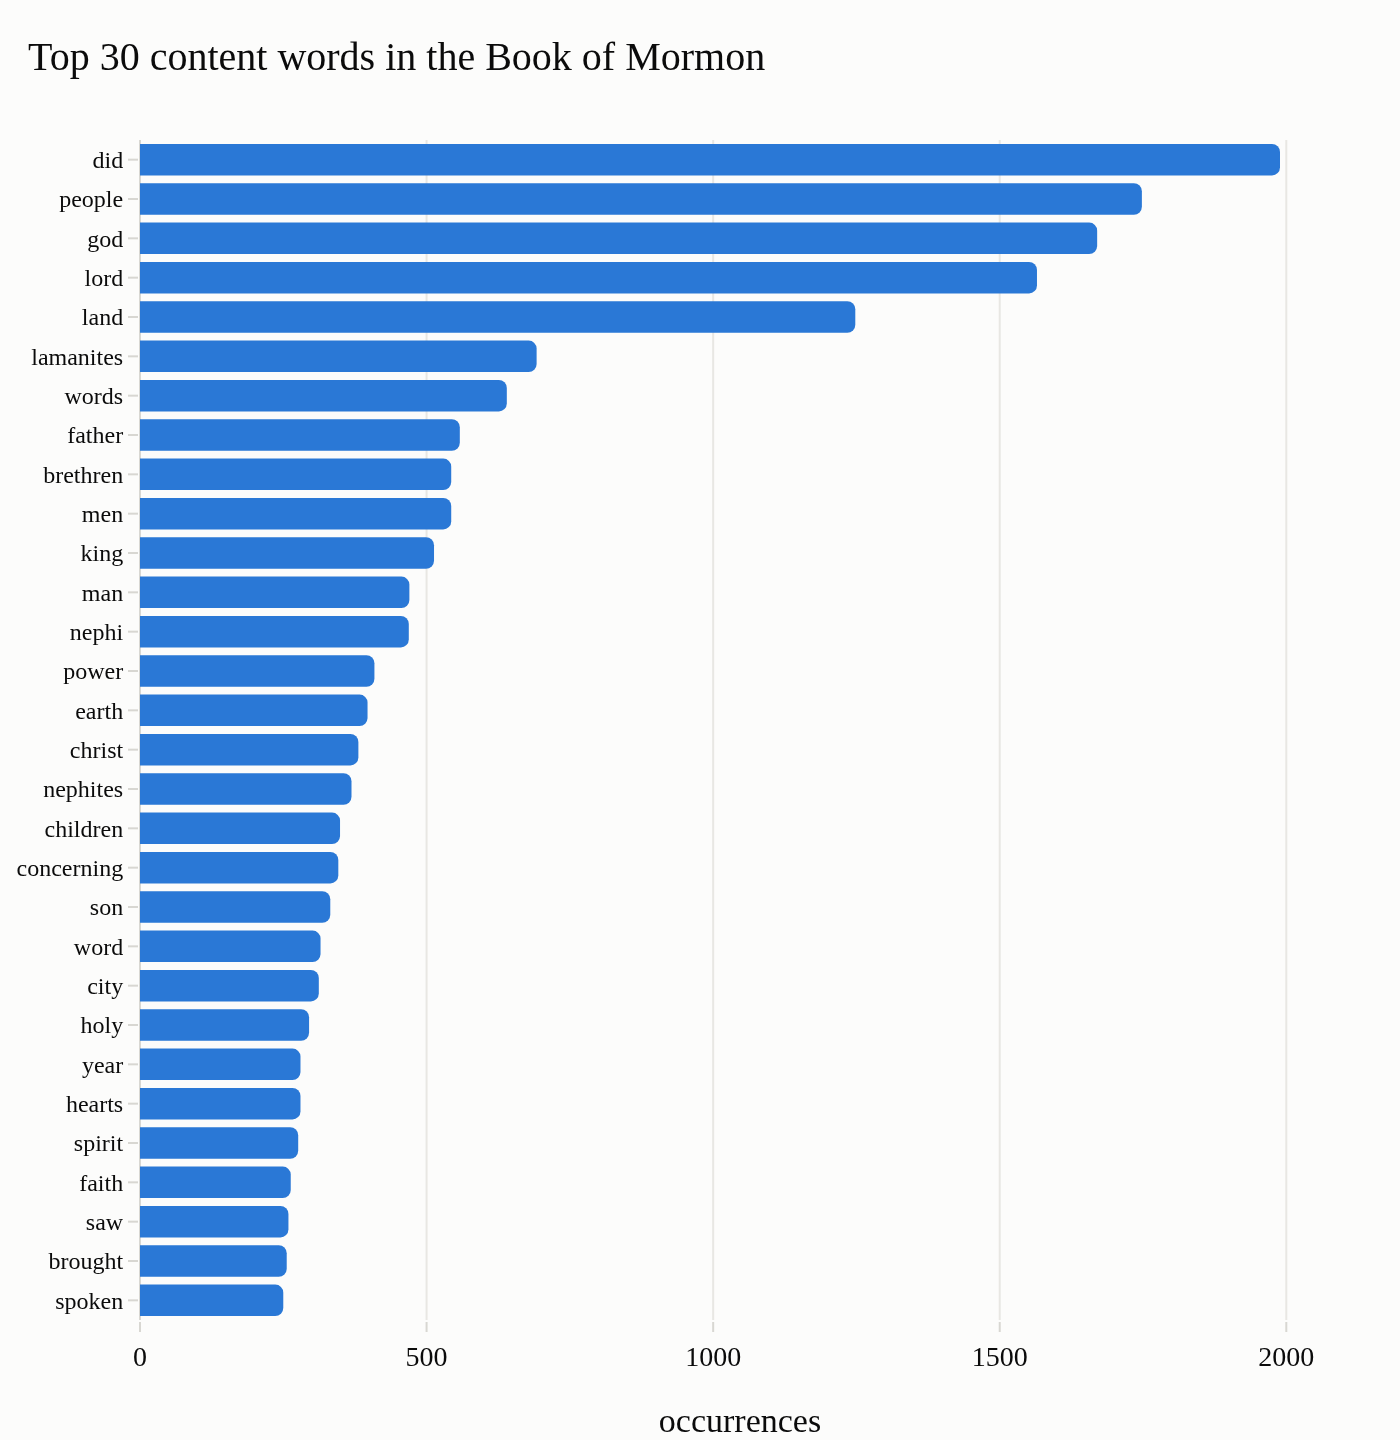

In [5]:
ARCHAIC_STOP = """unto yea behold beheld thou thee thy thine ye hath hast haths doth dost
wherefore therefore thereof therein thereby hitherto insomuch nevertheless notwithstanding
saith spake say said says speak come came cometh pass thing things also even now shall wilt
art doeth done exceedingly began begin according would could should may might must let us
o day days time place many great went forth away like manner know knew known""".split()
STOP = list(ENGLISH_STOP_WORDS) + ARCHAIC_STOP

def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())

all_tokens = tokenize(" ".join(bom.scripture_text))
content = [t for t in all_tokens if t not in set(STOP) and len(t) > 2]
top30 = Counter(content).most_common(30)

fig = go.Figure(go.Bar(
    y=[w for w, _ in top30][::-1], x=[c for _, c in top30][::-1], orientation="h",
    marker=dict(color="#2a78d6", cornerradius=4),
    hovertemplate="<b>%{y}</b> · %{x:,}×<extra></extra>"))
fig.update_layout(title="Top 30 content words in the Book of Mormon",
                  xaxis_title="occurrences", height=720,
                  yaxis=dict(gridcolor="rgba(0,0,0,0)", tickfont=dict(size=12)))
fig.show()

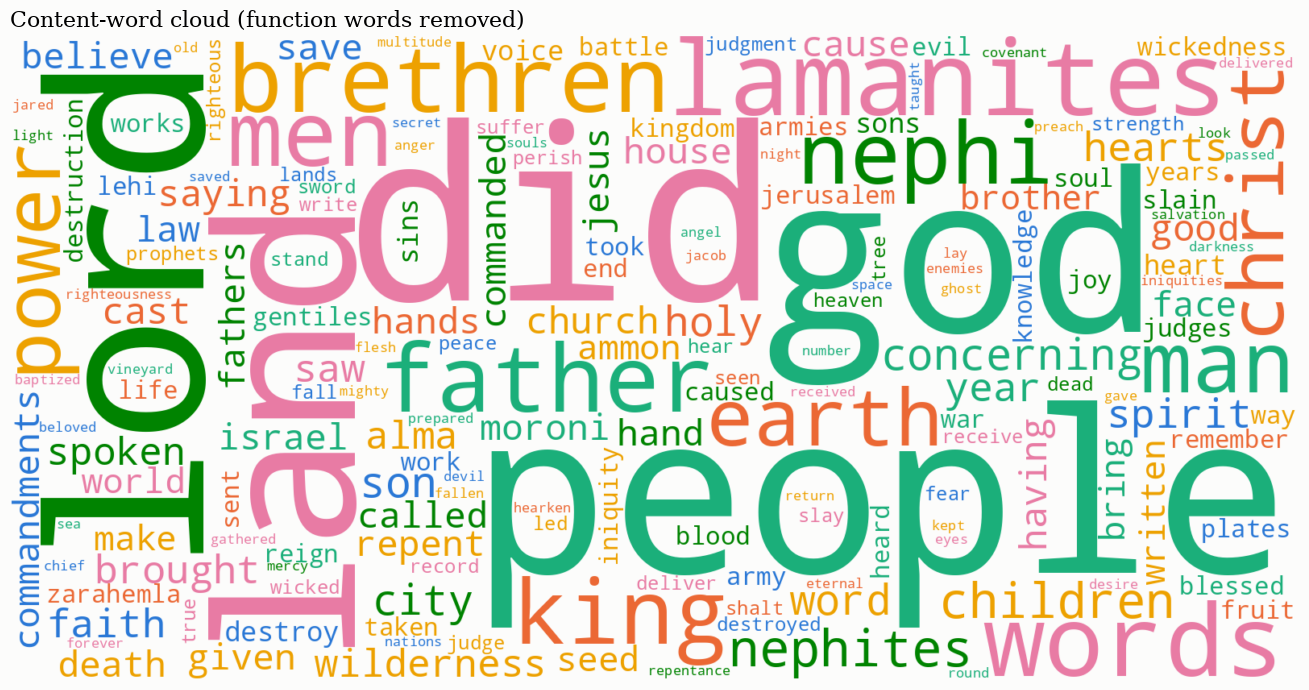

In [6]:
# A word cloud of the same content vocabulary — sized by frequency.
from wordcloud import WordCloud

freq = Counter(content)
palette_cycle = SERIES[:6]
wc = WordCloud(width=1600, height=800, background_color=SURFACE, max_words=180,
               color_func=lambda *a, **k: palette_cycle[np.random.randint(len(palette_cycle))],
               prefer_horizontal=0.95, font_path=None, random_state=RNG).generate_from_frequencies(freq)
plt.figure(figsize=(14, 7), facecolor=SURFACE)
plt.imshow(wc, interpolation="bilinear"); plt.axis("off")
plt.title("Content-word cloud (function words removed)", fontsize=16, family="serif", loc="left")
plt.tight_layout(); plt.show()

### 2b — What each book talks about *distinctively*

TF-IDF asks: which words does this book use far more than the others do? This surfaces each book's fingerprint — names, settings, and preoccupations — rather than the shared religious vocabulary.

In [7]:
book_docs = bom.groupby("book_title", observed=True).scripture_text.apply(" ".join).reindex(BOOK_ORDER)

tf = TfidfVectorizer(stop_words=STOP, token_pattern=r"[a-z]{3,}", lowercase=True,
                     sublinear_tf=True, min_df=2)
X_books = tf.fit_transform(book_docs)
vocab = np.array(tf.get_feature_names_out())

rows = []
for i, book in enumerate(BOOK_ORDER):
    top = X_books[i].toarray().ravel().argsort()[::-1][:8]
    rows.append({"book": book, "distinctive words": ", ".join(vocab[top])})
pd.DataFrame(rows).style.hide(axis="index").set_properties(**{"text-align": "left", "font-size": "13px"})  .set_table_styles([{"selector": "th", "props": "text-align:left; font-size:13px;"}])

book,distinctive words
1 Nephi,"ship, gentiles, lemuel, ishmael, rod, laban, angel, multitudes"
2 Nephi,"ephraim, rod, zion, gentiles, nations, judah, chains, thorns"
Jacob,"vineyard, branches, natural, roots, trees, olive, tree, bad"
Enos,"enos, strugglings, goats, short, faith, heard, god, lord"
Jarom,"jarom, swept, land, face, write, did, plates, kept"
Omni,"mosiah, discovered, zarahemla, benjamin, amaleki, wilderness, seasons, coriantumr"
Words of Mormon,"benjamin, king, amaleki, crimes, false, plates, people, finish"
Mosiah,"abinadi, limhi, alma, helam, amulon, shilom, noah, bondage"
Alma,"amulek, teancum, sidon, alma, ammon, judges, moroni, zeezrom"
Helaman,"kishkumen, judges, pahoran, helaman, gadianton, ended, coriantumr, band"


## 3 · "And it came to pass"

The most famous phrase in the book. Where does it actually live? We normalize per 1,000 words so small books compete fairly — and then look at which other long formulas the record leans on.

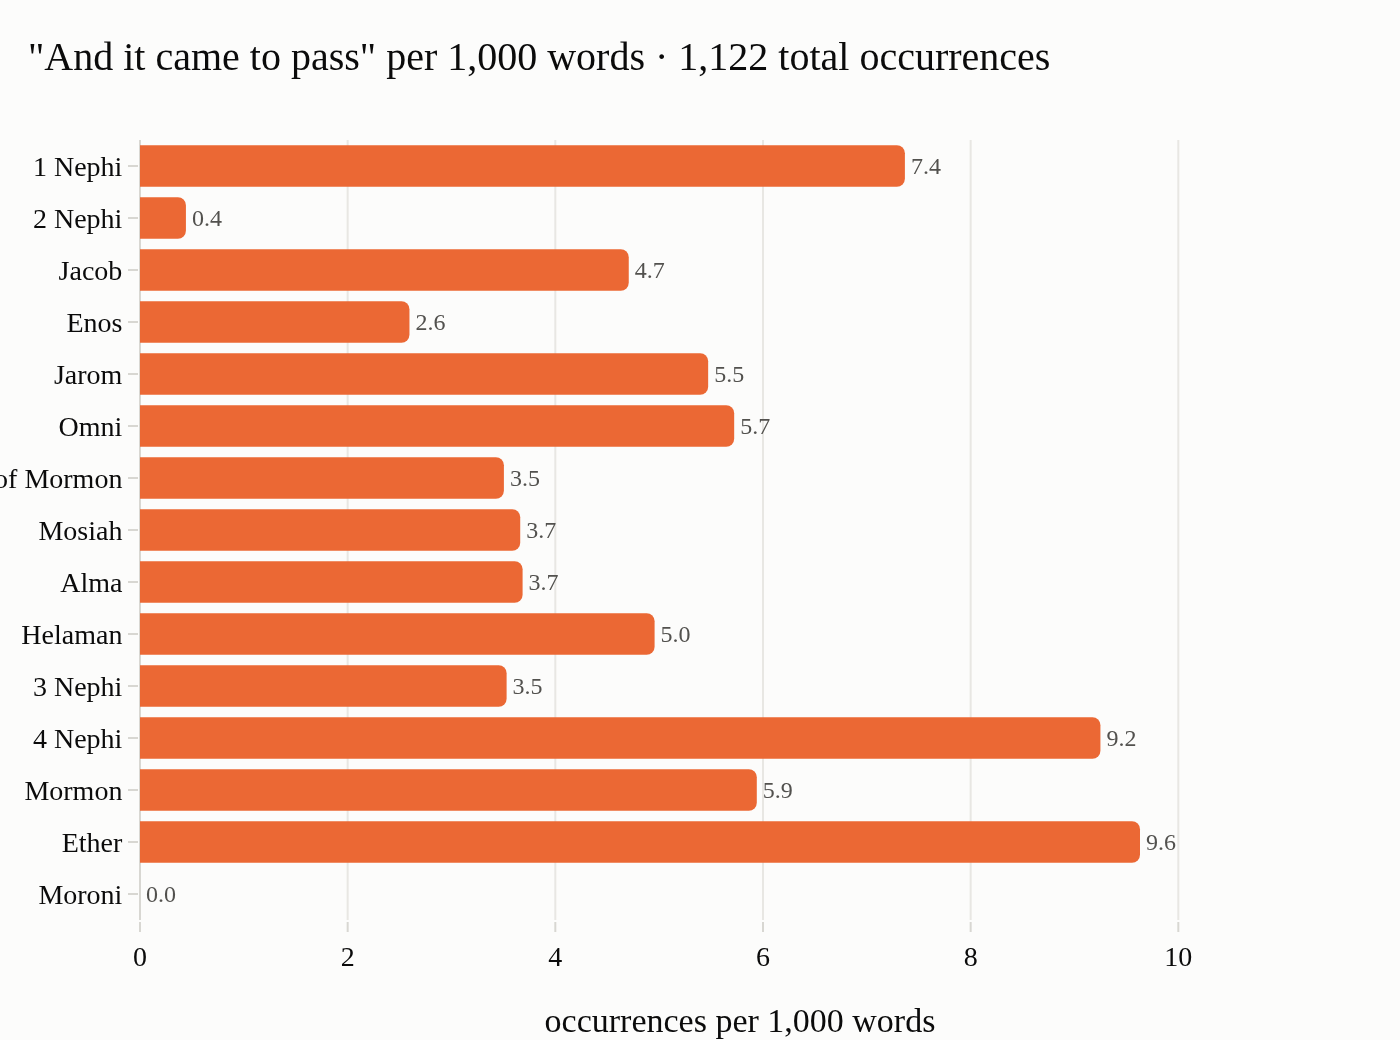

In [8]:
phrase = "and it came to pass"
counts = book_docs.str.lower().str.count(phrase)
rate = counts / book_stats.words * 1000

fig = go.Figure(go.Bar(
    y=rate.index[::-1], x=rate[::-1], orientation="h",
    marker=dict(color="#eb6834", cornerradius=4),
    text=[f"{r:.1f}" for r in rate[::-1]], textposition="outside",
    textfont=dict(color=INK2, size=12),
    hovertemplate="<b>%{y}</b><br>%{x:.2f} per 1,000 words<extra></extra>"))
fig.update_layout(title=f'"And it came to pass" per 1,000 words · {counts.sum():,} total occurrences',
                  xaxis_title="occurrences per 1,000 words", height=520,
                  xaxis_range=[0, rate.max()*1.2], yaxis=dict(gridcolor="rgba(0,0,0,0)"))
fig.show()

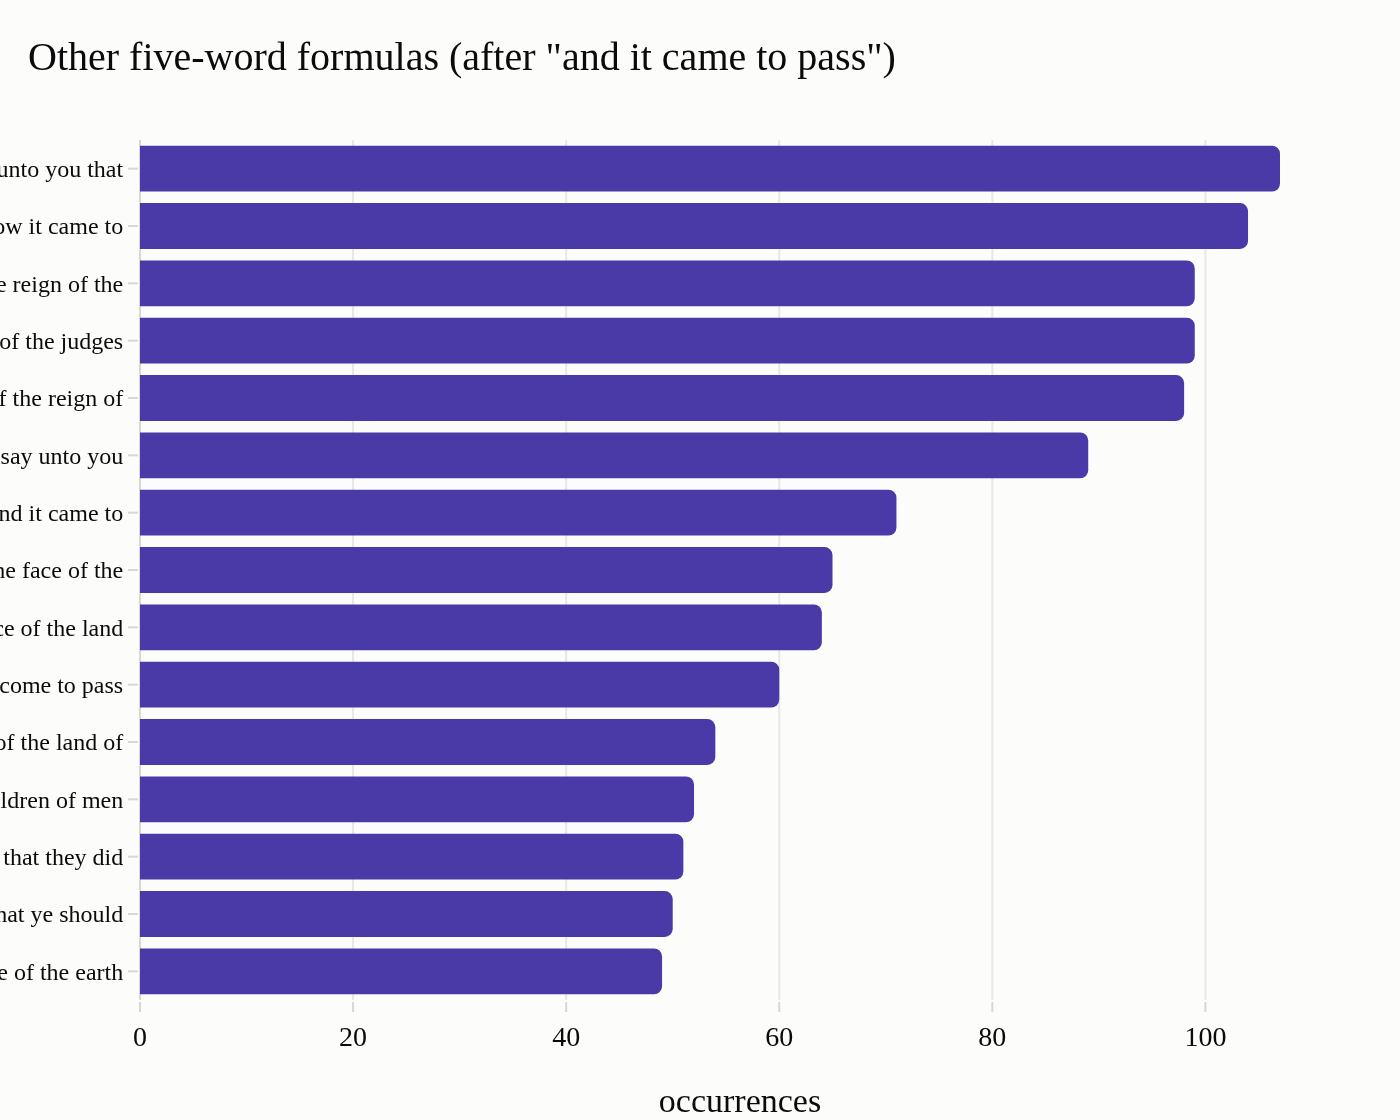

In [9]:
# Most-repeated 5-word formulas (excluding overlaps of "and it came to pass")
grams = Counter()
toks = all_tokens
for i in range(len(toks) - 4):
    grams[" ".join(toks[i:i+5])] += 1
top_grams = [(g, c) for g, c in grams.most_common(60) if "came to pass" not in g][:15]

fig = go.Figure(go.Bar(
    y=[g for g, _ in top_grams][::-1], x=[c for _, c in top_grams][::-1], orientation="h",
    marker=dict(color="#4a3aa7", cornerradius=4),
    hovertemplate="<b>%{y}</b> · %{x:,}×<extra></extra>"))
fig.update_layout(title='Other five-word formulas (after "and it came to pass")',
                  xaxis_title="occurrences", height=560,
                  yaxis=dict(gridcolor="rgba(0,0,0,0)", tickfont=dict(size=12)))
fig.show()

## 4 · Topic modeling — themes the machine finds on its own

Non-negative matrix factorization (NMF) decomposes the chapter × word matrix into a small set of **topics**: bundles of words that travel together. No labels are given; the topics below are whatever structure the text itself contains. We fit 12 topics on the 239 chapters.

In [10]:
N_TOPICS = 12
tf_ch = TfidfVectorizer(stop_words=STOP, token_pattern=r"[a-z]{3,}",
                        sublinear_tf=True, min_df=3, max_df=0.55)
X_ch = tf_ch.fit_transform(chapters.text)
vocab_ch = np.array(tf_ch.get_feature_names_out())

nmf = NMF(n_components=N_TOPICS, random_state=RNG, init="nndsvda", max_iter=600)
W = nmf.fit_transform(X_ch)          # chapters x topics
H = nmf.components_                  # topics x words

topic_words = [", ".join(vocab_ch[H[t].argsort()[::-1][:8]]) for t in range(N_TOPICS)]
topic_names = [vocab_ch[H[t].argsort()[::-1][:2]] for t in range(N_TOPICS)]
topic_names = [f"T{t+1}: {a} · {b}" for t, (a, b) in enumerate(topic_names)]

pd.DataFrame({"topic": topic_names, "top words": topic_words}).style.hide(axis="index")  .set_properties(**{"text-align": "left", "font-size": "13px"})  .set_table_styles([{"selector": "th", "props": "text-align:left; font-size:13px;"}])

topic,top words
T1: state · resurrection,"state, resurrection, good, evil, death, mercy, life, justice"
T2: moroni · lamanites,"moroni, lamanites, armies, city, army, battle, nephites, possession"
T3: plates · account,"plates, account, engraven, write, written, record, records, nephi"
T4: king · limhi,"king, limhi, bondage, priests, mosiah, alma, lamanites, wilderness"
T5: hosts · zion,"hosts, zion, israel, judah, hand, eat, make, glory"
T6: multitude · verily,"multitude, verily, jesus, disciples, heard, heaven, ghost, minister"
T7: year · judges,"year, judges, nephites, gadianton, ended, wickedness, robbers, reign"
T8: begat · jared,"begat, jared, brother, moron, com, kingdom, stead, daughters"
T9: ammon · lamoni,"ammon, lamoni, aaron, alma, king, prison, believe, lamanites"
T10: gentiles · israel,"gentiles, israel, house, seed, remnant, covenant, nations, jews"


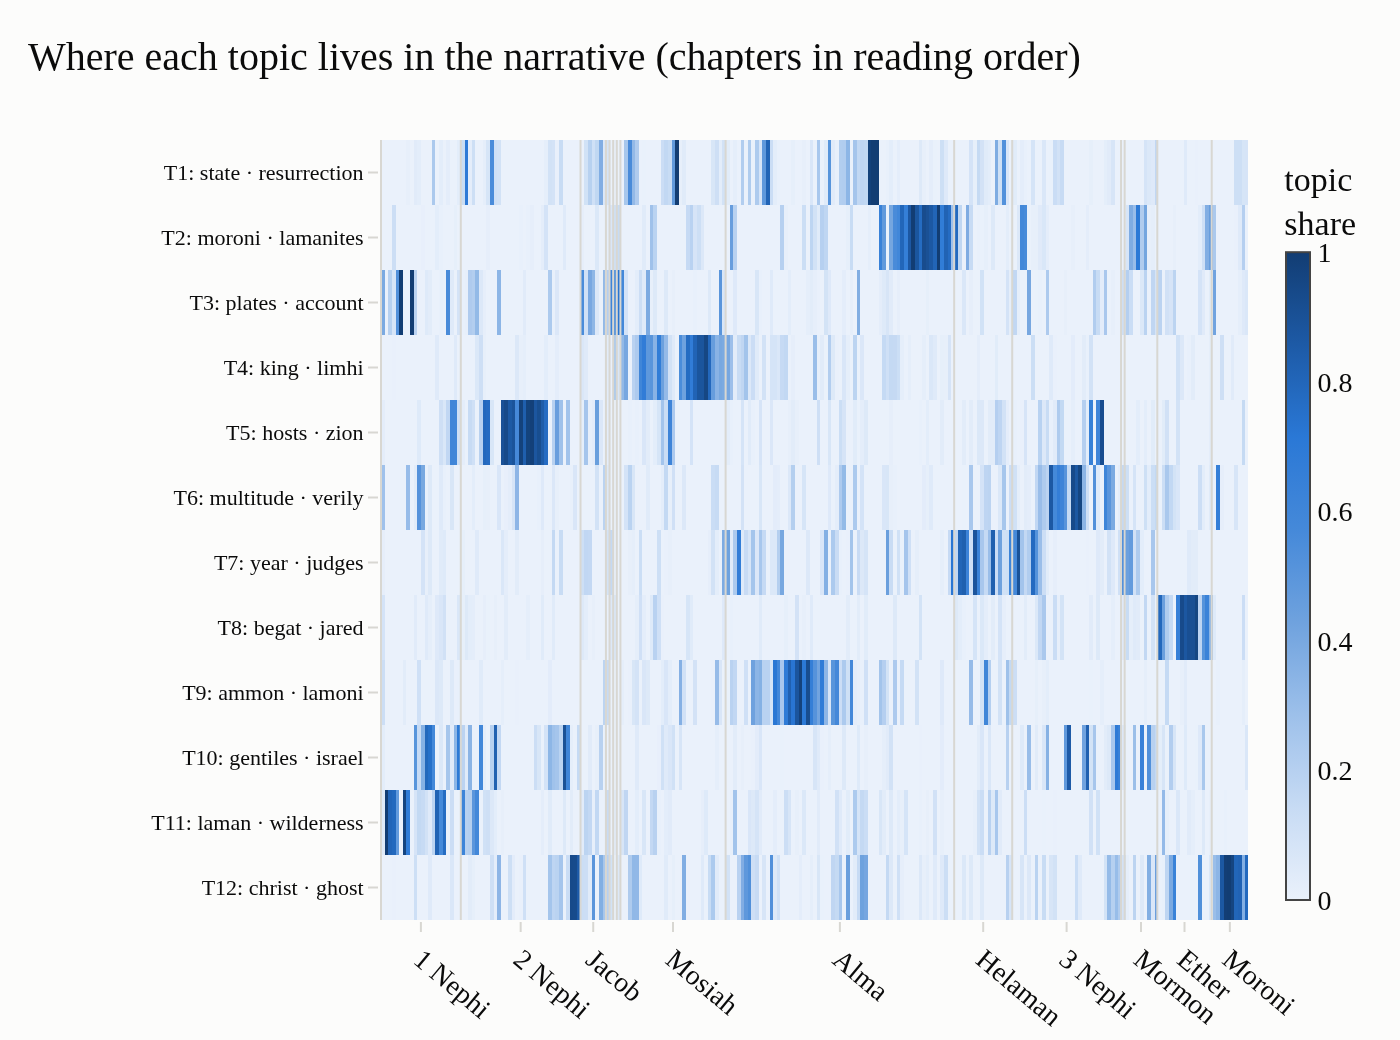

In [11]:
# Topic intensity across the narrative: chapters in reading order, one row per topic.
Wn = W / (W.sum(axis=1, keepdims=True) + 1e-12)
book_bounds = chapters.groupby("book_title", observed=True).seq.agg(["min", "max"])

fig = go.Figure(go.Heatmap(
    z=Wn.T, x=chapters.label, y=topic_names,
    colorscale=[[i/(len(SEQ_BLUE)-1), c] for i, c in enumerate(SEQ_BLUE)],
    hovertemplate="<b>%{x}</b><br>%{y}<br>share %{z:.2f}<extra></extra>",
    colorbar=dict(title="topic<br>share", thickness=12)))
for b, (lo, hi) in book_bounds.iterrows():
    fig.add_vline(x=lo - 0.5, line_width=1, line_color="#d8d7d2")
# only label books wide enough for the label to fit
big = book_bounds[book_bounds["max"] - book_bounds["min"] >= 4]
mid = (big["min"] + big["max"]) / 2
fig.update_layout(title="Where each topic lives in the narrative (chapters in reading order)",
                  height=520, margin=dict(l=190),
                  xaxis=dict(tickmode="array", tickvals=mid, ticktext=big.index,
                             tickangle=40, showgrid=False),
                  yaxis=dict(autorange="reversed", tickfont=dict(size=11), showgrid=False))
fig.show()

## 5 · Do chapters fall into natural families? — clustering + UMAP

We cluster chapters with k-means on their TF-IDF vectors (k chosen by silhouette score), then flatten the ~9,000-dimensional word space to 2-D with UMAP so we can *see* the families. Points that sit close use similar language. Hover any point for the chapter.

In [12]:
sil = {}
for k in range(4, 13):
    km = KMeans(n_clusters=k, random_state=RNG, n_init=10).fit(X_ch)
    sil[k] = silhouette_score(X_ch, km.labels_)
K = max(sil, key=sil.get)
km = KMeans(n_clusters=K, random_state=RNG, n_init=25).fit(X_ch)
chapters["cluster"] = km.labels_

# Name each cluster by its most distinctive words (cluster centroid)
cluster_names = {}
for c in range(K):
    top = km.cluster_centers_[c].argsort()[::-1][:3]
    cluster_names[c] = " · ".join(vocab_ch[top])
print(f"best k = {K} (silhouette {sil[K]:.3f})")
for c in range(K):
    n = (chapters.cluster == c).sum()
    print(f"  cluster {c} ({n:>3} chapters): {cluster_names[c]}")

best k = 8 (silhouette 0.017)
  cluster 0 ( 36 chapters): lamanites · nephites · armies
  cluster 1 ( 32 chapters): plates · nephi · records
  cluster 2 ( 34 chapters): christ · jesus · ghost
  cluster 3 ( 20 chapters): king · lamanites · limhi
  cluster 4 ( 24 chapters): alma · judges · church
  cluster 5 ( 26 chapters): evil · state · good
  cluster 6 ( 11 chapters): begat · jared · brother
  cluster 7 ( 56 chapters): israel · house · gentiles


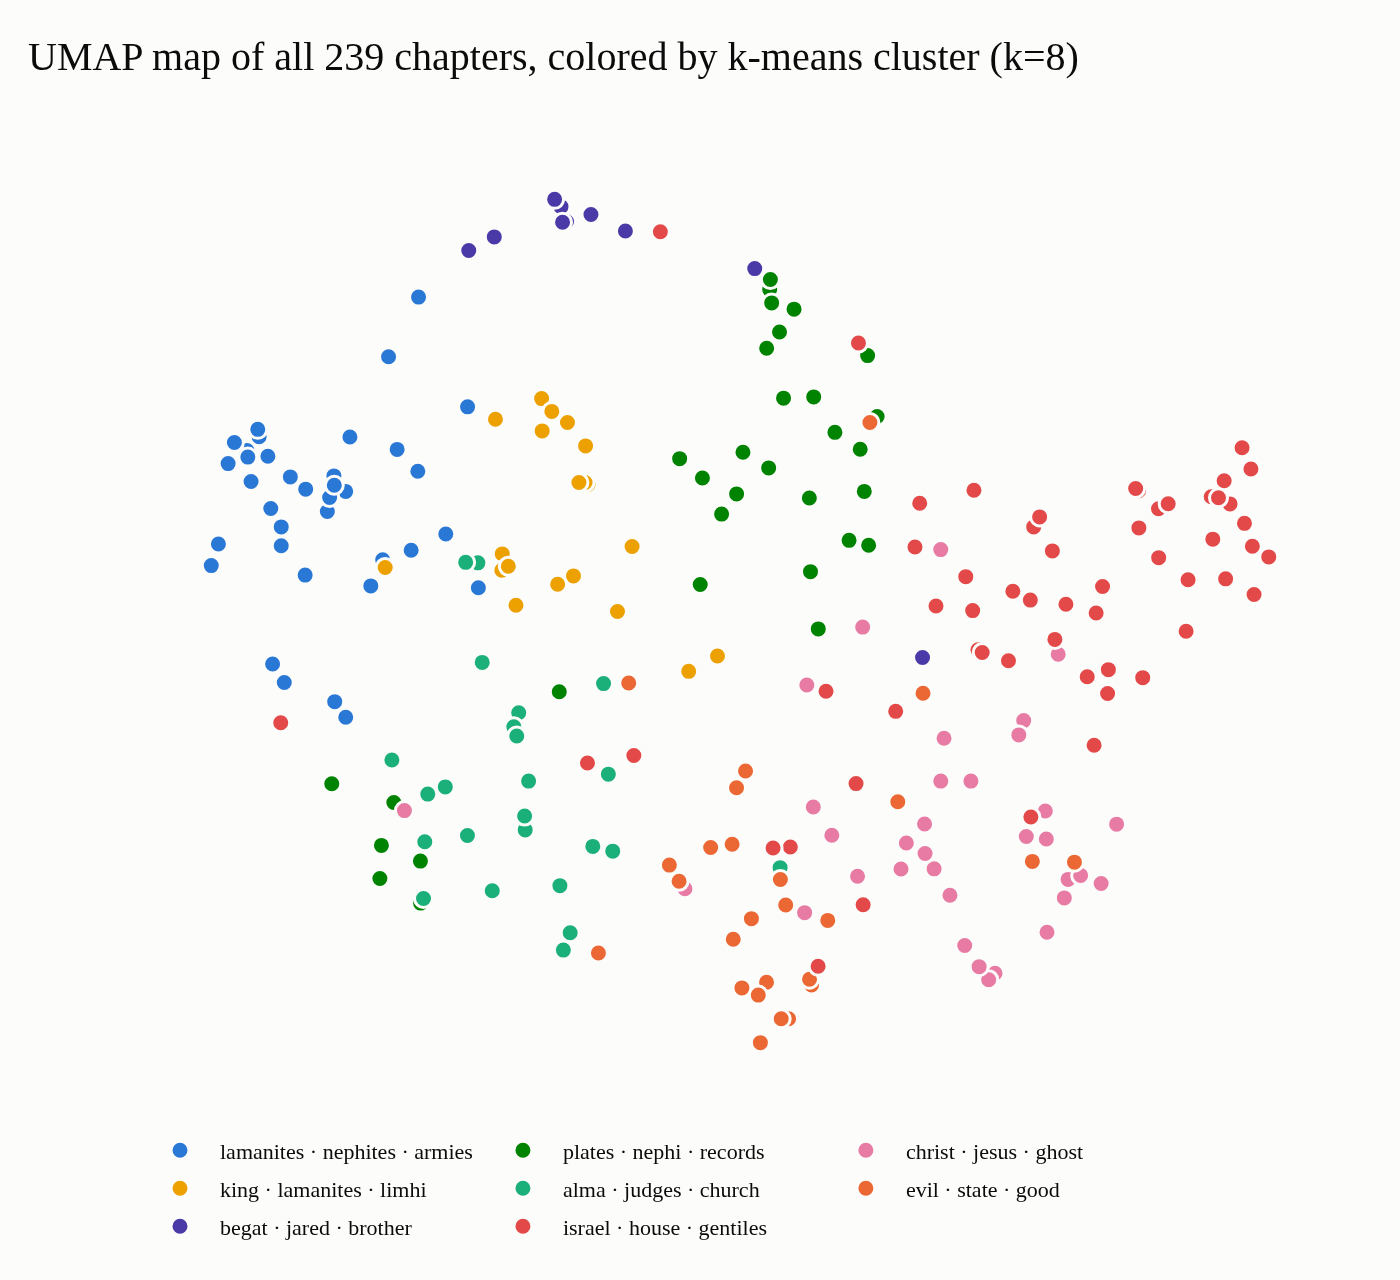

In [13]:
import umap
emb = umap.UMAP(n_neighbors=15, min_dist=0.15, metric="cosine",
                random_state=RNG).fit_transform(X_ch)
chapters["x"], chapters["y"] = emb[:, 0], emb[:, 1]

fig = go.Figure()
for c in range(K):
    sub = chapters[chapters.cluster == c]
    fig.add_trace(go.Scatter(
        x=sub.x, y=sub.y, mode="markers", name=cluster_names[c],
        marker=dict(size=9, color=SERIES[c % len(SERIES)], line=dict(width=1.5, color=SURFACE)),
        text=sub.label, hovertemplate="<b>%{text}</b><extra>" + cluster_names[c] + "</extra>"))
fig.update_layout(title=f"UMAP map of all 239 chapters, colored by k-means cluster (k={K})",
                  height=640, xaxis=dict(visible=False), yaxis=dict(visible=False),
                  legend=dict(orientation="h", yanchor="top", y=-0.02, font=dict(size=11)))
fig.show()

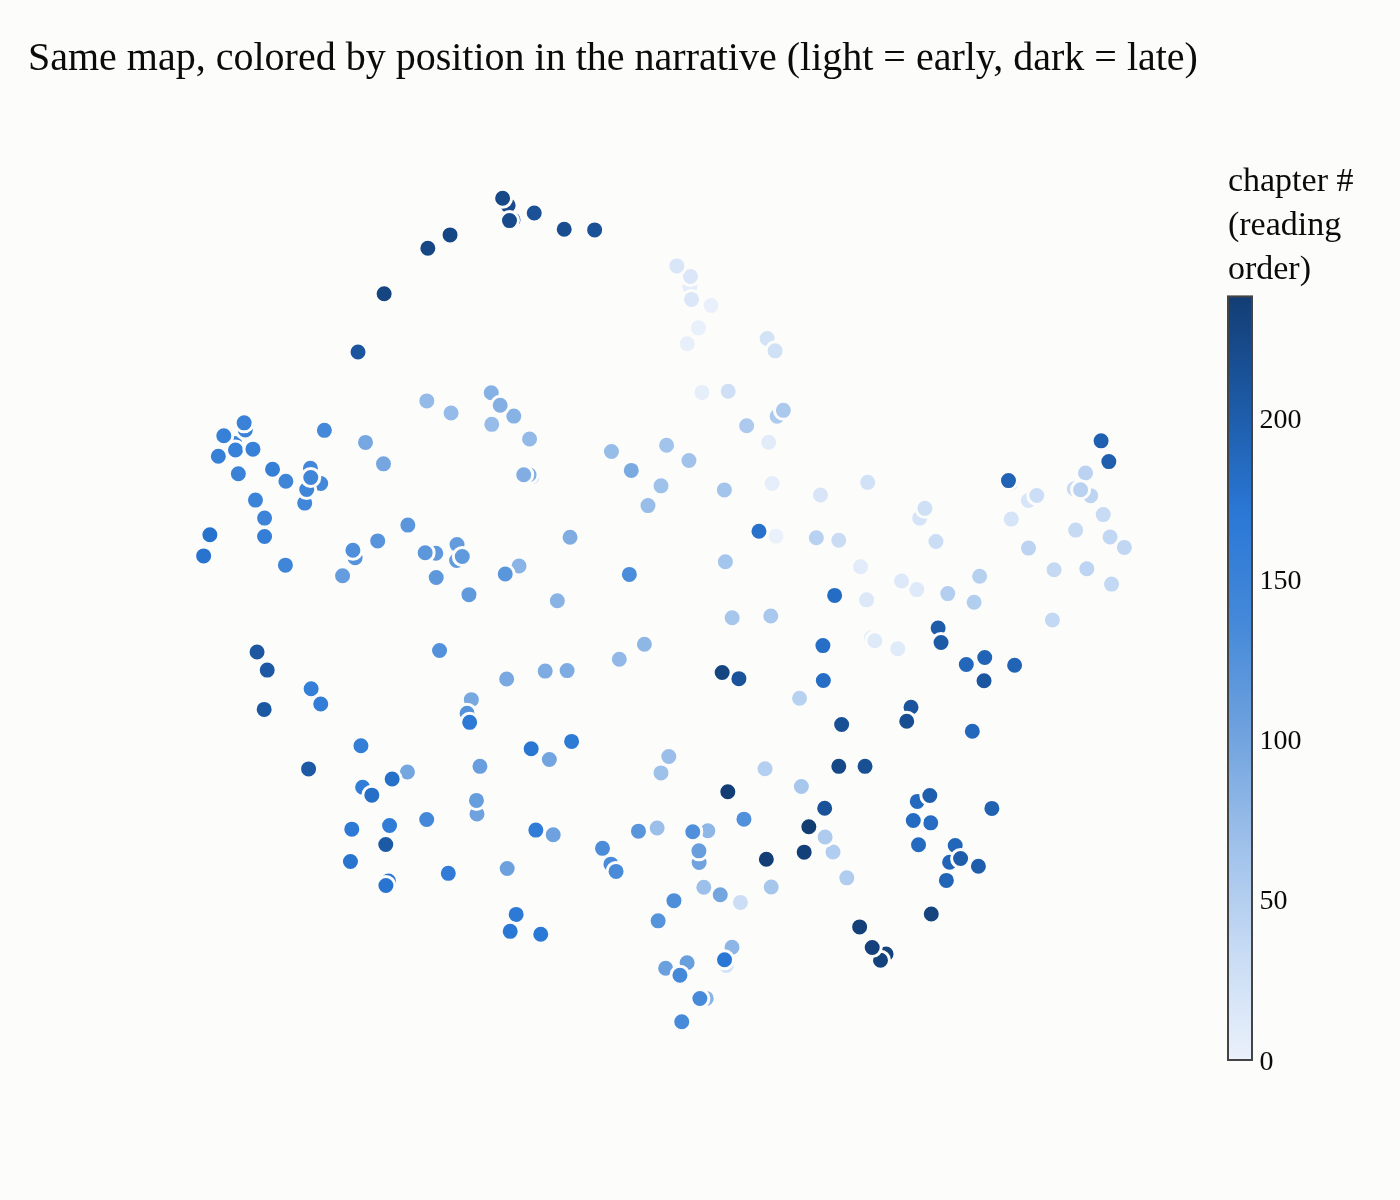

In [14]:
# Same map, colored by narrative position — does reading order survive the projection?
fig = go.Figure(go.Scatter(
    x=chapters.x, y=chapters.y, mode="markers",
    marker=dict(size=9, color=chapters.seq, line=dict(width=1.5, color=SURFACE),
                colorscale=[[i/(len(SEQ_BLUE)-1), c] for i, c in enumerate(SEQ_BLUE)],
                colorbar=dict(title="chapter #<br>(reading<br>order)", thickness=12)),
    text=chapters.label, hovertemplate="<b>%{text}</b><extra></extra>"))
fig.update_layout(title="Same map, colored by position in the narrative (light = early, dark = late)",
                  height=600, xaxis=dict(visible=False), yaxis=dict(visible=False))
fig.show()

## 6 · Stylometry — books by *style*, not subject

Now we ignore content entirely and measure only **function words** (*and, of, that, unto, did…*) — the unconscious connective tissue of prose that authorship studies rely on. Each book becomes a profile of function-word rates; we standardize and let hierarchical clustering draw the family tree.

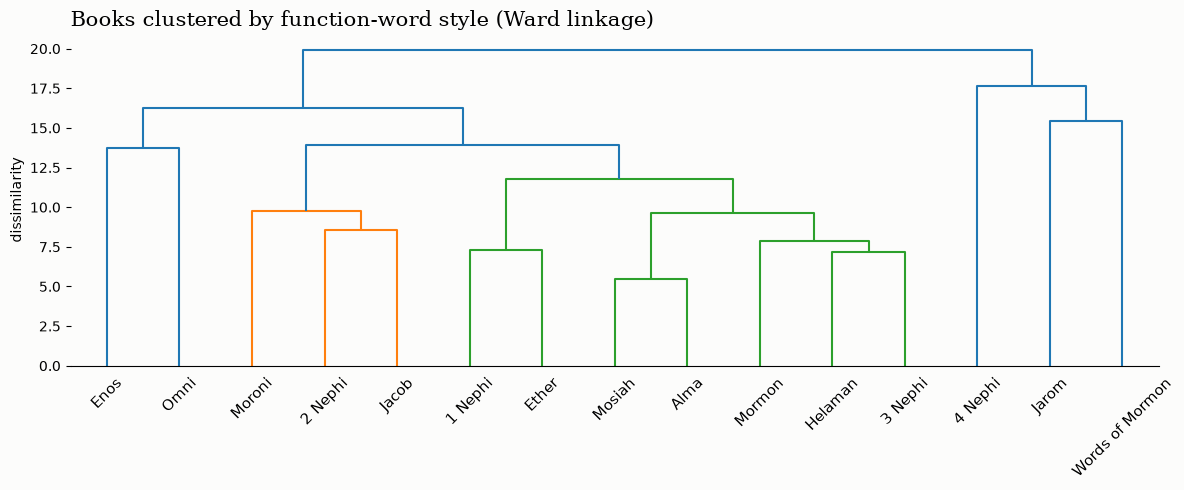

In [15]:
FUNCTION_WORDS = """and the of that to in it he they i unto for be his my me we my ye them him
which was were is are am not no but a an with by as have had hath did do done shall will
would should this these those there their our your when after before because if or so
all again out up upon among against now then thus behold yea o wherefore therefore""".split()
FUNCTION_WORDS = sorted(set(FUNCTION_WORDS))

cv = CountVectorizer(vocabulary=FUNCTION_WORDS, token_pattern=r"[a-z]+", lowercase=True)
F = cv.fit_transform(book_docs).toarray().astype(float)
F = F / book_stats.words.values[:, None] * 1000          # rate per 1,000 words
Fz = StandardScaler().fit_transform(F)

Z = linkage(Fz, method="ward")
fig_, ax = plt.subplots(figsize=(12, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
dendrogram(Z, labels=list(book_docs.index), leaf_rotation=45, leaf_font_size=11,
           color_threshold=0.6 * Z[:, 2].max(), ax=ax,
           link_color_func=None)
ax.set_title("Books clustered by function-word style (Ward linkage)", family="serif",
             fontsize=15, loc="left")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.set_ylabel("dissimilarity")
plt.tight_layout(); plt.show()

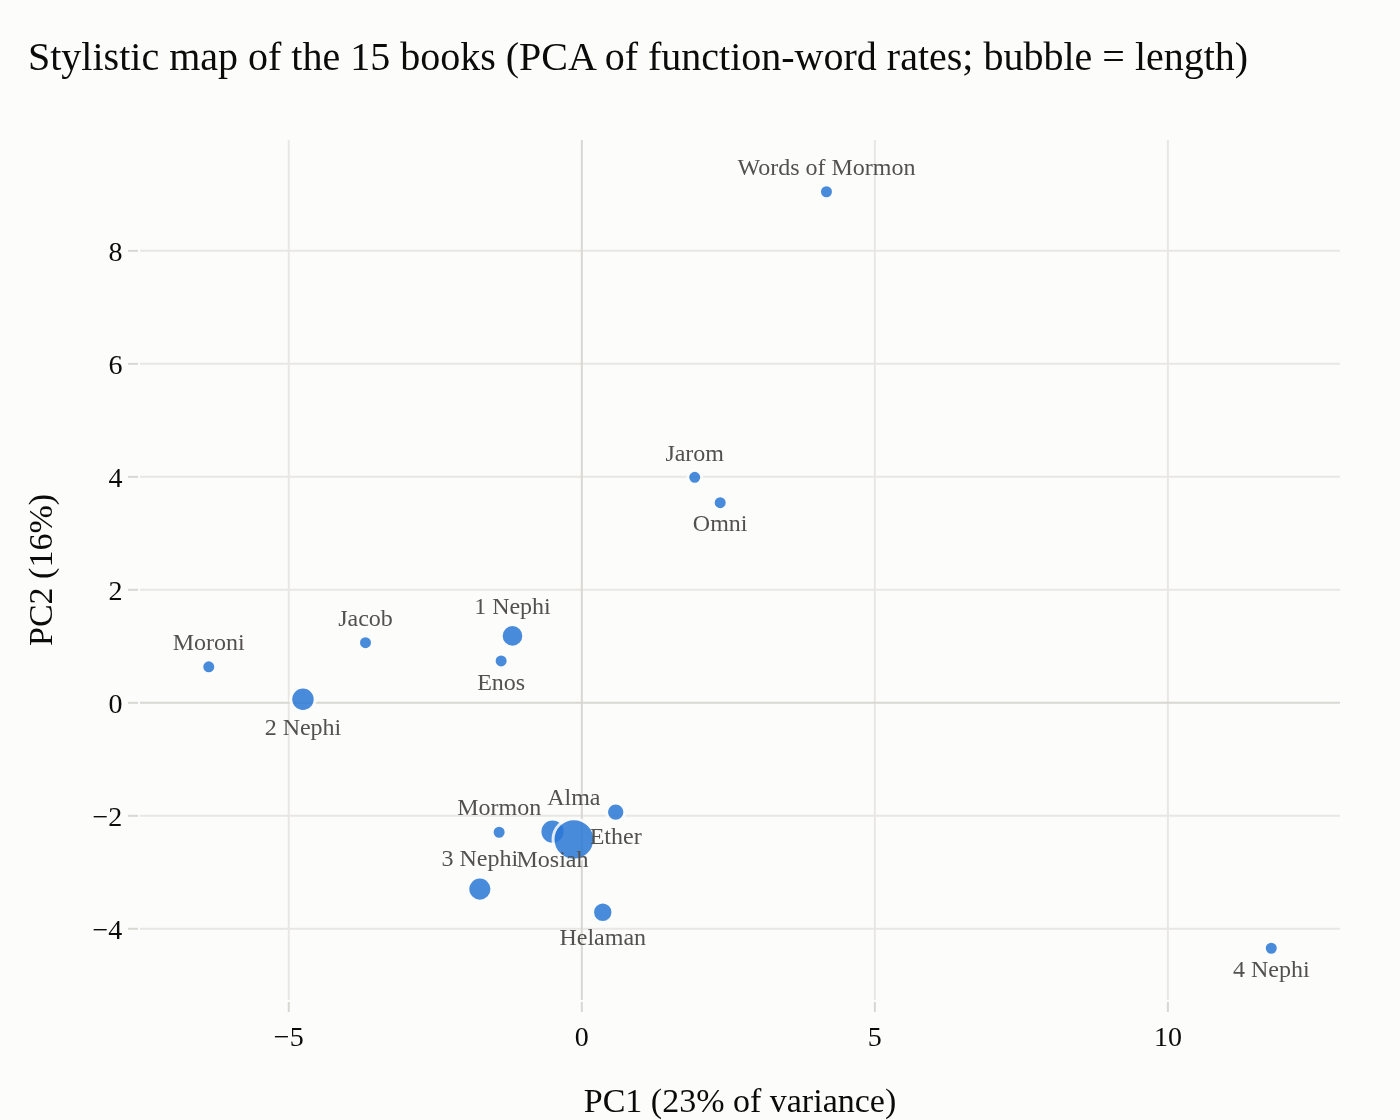

In [16]:
pca = PCA(n_components=2, random_state=RNG)
P = pca.fit_transform(Fz)
sizes = np.clip(np.sqrt(book_stats.words.values) / 14, 7, 30)
positions = ["top center" if i % 2 == 0 else "bottom center" for i in range(len(book_docs))]

fig = go.Figure(go.Scatter(
    x=P[:, 0], y=P[:, 1], mode="markers+text", text=list(book_docs.index),
    textposition=positions, textfont=dict(size=12, color=INK2),
    marker=dict(size=sizes, color="#2a78d6", line=dict(width=1.5, color=SURFACE), opacity=0.85),
    hovertemplate="<b>%{text}</b><extra></extra>"))
fig.update_layout(title="Stylistic map of the 15 books (PCA of function-word rates; bubble = length)",
                  height=560,
                  xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)",
                  yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
fig.show()

## 7 · Verse echoes — the most similar verse pairs across different books

Cosine similarity over TF-IDF verse vectors, keeping only pairs from **different books**. This surfaces quotation, deliberate echo, and formula — passages that repeat across the record, found with zero supervision.

In [17]:
tf_v = TfidfVectorizer(stop_words="english", token_pattern=r"[a-z]{3,}", min_df=2, sublinear_tf=True)
Xv = tf_v.fit_transform(bom.scripture_text)
S = cosine_similarity(Xv, dense_output=False)

pairs = []
S = S.tocoo()
for i, j, v in zip(S.row, S.col, S.data):
    if i < j and v > 0.72 and bom.book_title[i] != bom.book_title[j]:
        pairs.append((v, i, j))
pairs.sort(reverse=True)

seen, rows = set(), []
for v, i, j in pairs:
    if i in seen or j in seen:
        continue
    seen.update((i, j))
    rows.append({"similarity": f"{v:.2f}",
                 "verse A": bom.verse_title[i], "text A": bom.scripture_text[i][:160] + "…",
                 "verse B": bom.verse_title[j], "text B": bom.scripture_text[j][:160] + "…"})
    if len(rows) == 12:
        break
pd.DataFrame(rows).style.hide(axis="index")  .set_properties(**{"text-align": "left", "font-size": "12px", "vertical-align": "top"})  .set_table_styles([{"selector": "th", "props": "text-align:left; font-size:12px;"}])

similarity,verse A,text A,verse B,text B
1.00,2 Nephi 8:25,"Shake thyself from the dust; arise, sit down, O Jerusalem; loose thyself from the bands of thy neck, O captive daughter of Zion.…",3 Nephi 20:37,"Shake thyself from the dust; arise, sit down, O Jerusalem; loose thyself from the bands of thy neck, O captive daughter of Zion.…"
1.00,Mosiah 15:31,The Lord hath made bare his holy arm in the eyes of all the nations; and all the ends of the earth shall see the salvation of our God.…,3 Nephi 16:20,The Lord hath made bare his holy arm in the eyes of all the nations; and all the ends of the earth shall see the salvation of God.…
1.00,Mosiah 15:30,"Break forth into joy, sing together, ye waste places of Jerusalem; for the Lord hath comforted his people, he hath redeemed Jerusalem.…",3 Nephi 16:19,"Break forth into joy, sing together, ye waste places of Jerusalem; for the Lord hath comforted his people, he hath redeemed Jerusalem.…"
1.00,Mosiah 12:22,Thy watchmen shall lift up the voice; with the voice together shall they sing; for they shall see eye to eye when the Lord shall bring again Zion;…,3 Nephi 16:18,"Thy watchmen shall lift up the voice; with the voice together shall they sing, for they shall see eye to eye when the Lord shall bring again Zion.…"
1.00,1 Nephi 21:26,"And I will feed them that oppress thee with their own flesh; they shall be drunken with their own blood as with sweet wine; and all flesh shall know that I, the…",2 Nephi 6:18,"And I will feed them that oppress thee, with their own flesh; and they shall be drunken with their own blood as with sweet wine; and all flesh shall know that I…"
0.99,1 Nephi 21:22,"Thus saith the Lord God: Behold, I will lift up mine hand to the Gentiles, and set up my standard to the people; and they shall bring thy sons in their arms, an…",2 Nephi 6:6,"And now, these are the words: Thus saith the Lord God: Behold, I will lift up mine hand to the Gentiles, and set up my standard to the people; and they shall br…"
0.99,Mosiah 12:21,How beautiful upon the mountains are the feet of him that bringeth good tidings; that publisheth peace; that bringeth good tidings of good; that publisheth salv…,3 Nephi 20:40,"And then shall they say: How beautiful upon the mountains are the feet of him that bringeth good tidings unto them, that publisheth peace; that bringeth good ti…"
0.97,Mosiah 12:23,"Break forth into joy; sing together ye waste places of Jerusalem; for the Lord hath comforted his people, he hath redeemed Jerusalem;…",3 Nephi 20:34,"Then shall they break forth into joy--Sing together, ye waste places of Jerusalem; for the Father hath comforted his people, he hath redeemed Jerusalem.…"
0.96,Alma 53:23,And thus ended the twenty and eighth year of the reign of the judges over the people of Nephi.…,Helaman 6:41,And it came to pass that thus ended the sixty and eighth year of the reign of the judges over the people of Nephi.…
0.96,2 Nephi 8:24,"Awake, awake, put on thy strength, O Zion; put on thy beautiful garments, O Jerusalem, the holy city; for henceforth there shall no more come into thee the unci…",3 Nephi 20:36,"And then shall be brought to pass that which is written: Awake, awake again, and put on thy strength, O Zion; put on thy beautiful garments, O Jerusalem, the ho…"


## 8 · Vocabulary novelty — where new language enters the record

Reading in order, what fraction of each chapter's distinct words have never appeared before? Early chapters are all-new by definition; after that, spikes mark places where genuinely fresh vocabulary arrives (new quoted material, new subject matter, new voices).

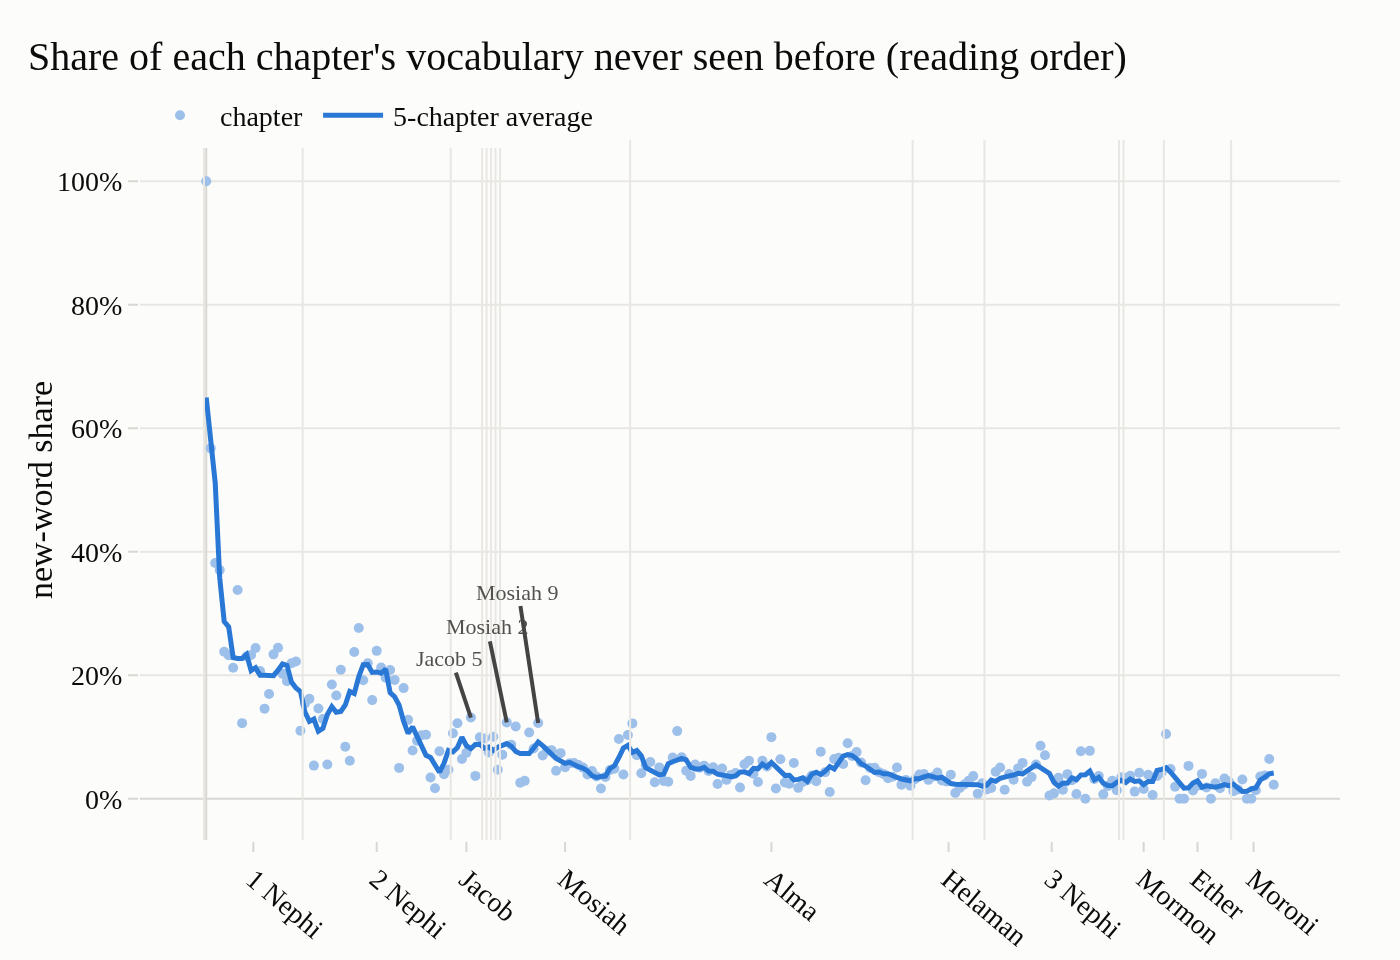

In [18]:
seen_words, novelty = set(), []
for t in chapters.text:
    toks = set(tokenize(t))
    new = toks - seen_words
    novelty.append(len(new) / len(toks))
    seen_words |= toks
chapters["novelty"] = novelty
roll = chapters.novelty.rolling(5, center=True, min_periods=1).mean()

fig = go.Figure()
fig.add_trace(go.Scatter(x=chapters.seq, y=chapters.novelty, mode="markers",
                         marker=dict(size=5, color="#9dc0ea"), name="chapter",
                         text=chapters.label,
                         hovertemplate="<b>%{text}</b><br>%{y:.0%} new words<extra></extra>"))
fig.add_trace(go.Scatter(x=chapters.seq, y=roll, mode="lines",
                         line=dict(width=2.5, color="#2a78d6"), name="5-chapter average",
                         hoverinfo="skip"))
for b, (lo, hi) in book_bounds.iterrows():
    fig.add_vline(x=lo - 0.5, line_width=1, line_color="#e8e7e3")
fig.update_layout(title="Share of each chapter's vocabulary never seen before (reading order)",
                  height=480, yaxis_tickformat=".0%", yaxis_title="new-word share",
                  xaxis=dict(tickmode="array", tickvals=mid, ticktext=big.index,
                             tickangle=40, showgrid=False),
                  legend=dict(orientation="h", y=1.08))
# annotate the top spikes after the two opening books
late = chapters[chapters.seq > 55].nlargest(3, "novelty")
for n, (_, r) in enumerate(late.iterrows()):
    fig.add_annotation(x=r.seq, y=r.novelty, text=r.label, showarrow=True, arrowhead=0,
                       ay=-30 - 18 * n, font=dict(size=11, color=INK2))
fig.show()

---
## Takeaways

A few things the algorithms found without being told anything about the text:

- **The record is extraordinarily lopsided.** Alma alone is ~32% of the words; Alma + Mosiah + 2 Nephi + 3 Nephi together are about two-thirds of the entire book, while seven books contribute under 1% each.
- **"And it came to pass" appears 1,122 times** (~4 per 1,000 words), but its rate varies enormously by book — it saturates the fast-moving narrative books (Ether, 1 Nephi) and nearly vanishes in the sermon books (Moroni, and the doctrinal middle of 2 Nephi).
- **Topics = genres.** NMF cleanly separates war chronicle, record-keeping asides, the Ammon/Lamoni mission, Jaredite genealogy, Isaiah/Zion material, and doctrinal discourse — and the heatmap shows each living in a contiguous stretch of the narrative. The book behaves like several interleaved genres, and the machine finds the seams.
- **The clustering rediscovers the book's own structure.** The largest chapter cluster is the Israel/covenant/gentiles material spanning 2 Nephi and 3 Nephi; war chapters, "plates and records" chapters, and the Jaredite chapters each form their own tight families.
- **Stylometry echoes the claimed authorship structure.** Using only function words (no content), the long abridged narrative books (Mosiah, Alma, Helaman, 3 Nephi, Mormon, Ether) cluster together, while the first-person small-plates sermon books (2 Nephi, Jacob, with Moroni) form a separate stylistic family, and the one-chapter books sit apart as their own group.
- **The verse-echo search independently discovers the Isaiah quotations.** The most similar cross-book verse pairs are nearly verbatim repetitions — Mosiah 12–15 ↔ 3 Nephi 16, 2 Nephi 8 ↔ 3 Nephi 20, 1 Nephi 21 ↔ 2 Nephi 6 — i.e., the same Isaiah passages quoted in different places, plus formulaic echoes across books.
- **New vocabulary arrives in bursts,** above all with the Isaiah block in 2 Nephi 12–24; after Mosiah the record settles to only a few percent new words per chapter, with small bumps where new voices or subjects enter.

Everything above is unsupervised — rerun the notebook and it all regenerates from the raw verse text.